<a href="https://colab.research.google.com/github/dominicpruss/testRepo/blob/main/notebooks/run_Cellpose-SAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cellpose-SAM: superhuman generalization for cellular segmentation

Marius Pachitariu, Michael Rariden, Carsen Stringer

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

This notebook shows how to process your own 2D or 3D images, saved on Google Drive.

This notebook is adapted from the notebook by Pradeep Rajasekhar, inspired by the [ZeroCostDL4Mic notebook series](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki).

### Make sure you have GPU access enabled by going to Runtime -> Change Runtime Type -> Hardware accelerator and selecting GPU

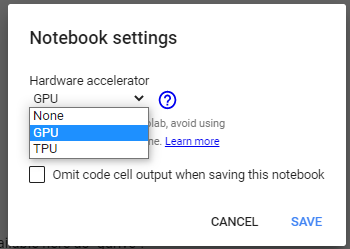

### Mount your google drive

Run this cell to connect your Google Drive to colab:
* Click on the URL.
* Sign in your Google Account.

You will either have to:
* copy the authorisation code and enter it into box below OR
* in the new google colab, you can just click "Allow" and it should connect.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



Then click on "Folder" icon on the Left, press the refresh button. Your Google Drive folder should now be available here as "gdrive".


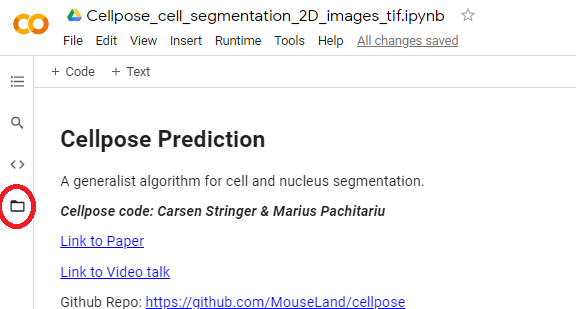

Click on the triangle icon and it will allow you to access whole drive. Navigate to the folder containing your images. Once you are there, click on the three dots on the right of the folder and select "Copy Path"

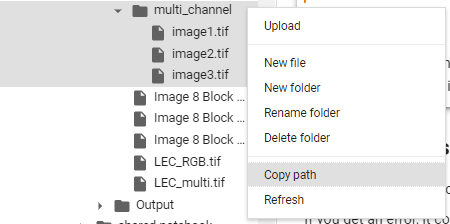

Copy and paste this path in the **dir** string below

### Install Cellpose-SAM


In [3]:
!uv pip install git+https://www.github.com/mouseland/cellpose.git
!uv pip install git+https://github.com/facebookresearch/dinov3.git

Using Python 3.13.15 environment at: /usr
Resolved 43 packages in 8.99s
Prepared 6 packages in 844ms
Installed 6 packages in 5ms
 + cellpose==4.2.1.1 (from git+https://www.github.com/mouseland/cellpose.git@a54cb48849b7e225a81e8e43dcb042d42427f543)
 + fastremap==1.20.0
 + fill-voids==2.1.2
 + imagecodecs==2026.8.16
 + roifile==2026.9.22
 + segment-anything==1.0
Using Python 3.13.15 environment at: /usr
Resolved 49 packages in 2.99s
Prepared 5 packages in 518ms
Installed 5 packages in 10ms
 + dinov3==0.0.1 (from git+https://github.com/facebookresearch/dinov3.git@6876159a11b4df116f30f667f8c9888617df0751)
 + ftfy==6.3.1
 + lightning-utilities==0.15.3
 + submitit==1.5.4
 + torchmetrics==1.9.0


Check GPU and instantiate model - will download weights.

In [4]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

### You can also use other pretrained models, like the DINO models
# model = models.CellposeModel(gpu=True, pretrained_model="cpdino")
# model = models.CellposeModel(gpu=True, pretrained_model="cpdino-vitb")

creating new log file
[GUI INFO] : WRITING LOG OUTPUT TO /root/.cellpose/run.log

cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.13.15 
torch version:  	2.11.0+cu130
2026-10-07 19:01:02,940 [io INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-10-07 19:01:02,941 [io INFO] 
cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.13.15 
torch version:  	2.11.0+cu130
2026-10-07 19:01:03,334 [core INFO] ** TORCH CUDA version installed and working. **
2026-10-07 19:01:03,336 [core INFO] ** TORCH CUDA version installed and working. **
2026-10-07 19:01:03,337 [core INFO] >>>> using GPU (CUDA)
2026-10-07 19:01:03,339 [models INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam_v2" to /root/.cellpose/models/cpsam_v2



100%|██████████| 1.15G/1.15G [00:12<00:00, 97.2MB/s]


2026-10-07 19:01:19,289 [models INFO] >>>> loading model /root/.cellpose/models/cpsam_v2


Input directory with your images:

In [8]:
# *** change to your google drive folder path ***
dir = "/content/drive/MyDrive/test_cellpose"
dir = Path(dir)
if not dir.exists():
  raise FileNotFoundError("directory does not exist")

# *** change to your image extension ***
image_ext = ".png"

# list all files
files = natsorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])

if(len(files)==0):
  raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
else:
  print(f"{len(files)} images in folder:")

for f in files:
  print(f.name)

9 images in folder:
Day 4a.png
Day 4b.png
Day 7a.png
Day 7b.png
Day 14a.png
Day 14b.png
Day 14c.png
Day 14d.png
Day 14e.png


## Run Cellpose-SAM on one image in folder

Here are some of the parameters you can change:

* ***flow_threshold*** is  the  maximum  allowed  error  of  the  flows  for  each  mask.   The  default  is 0.4.
    *  **Increase** this threshold if cellpose is not returning as many masks as you’d expect (or turn off completely with 0.0)
    *   **Decrease** this threshold if cellpose is returning too many ill-shaped masks.

* ***cellprob_threshold*** determines proability that a detected object is a cell.   The  default  is 0.0.
    *   **Decrease** this threshold if cellpose is not returning as many masks as you’d expect or if masks are too small
    *   **Increase** this threshold if cellpose is returning too many masks esp from dull/dim areas.

* ***tile_norm_blocksize*** determines the size of blocks used for normalizing the image. The default is 0, which means the entire image is normalized together.
  You may want to change this to 100-200 pixels if you have very inhomogeneous brightness across your image.



In [9]:
img = io.imread(files[0])

print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')

your image has shape: (550, 800, 3). Assuming channel dimension is last with 3 channels


### Channel Selection:

- Use the dropdowns below to select the _zero-indexed_ channels of your image to segment. The order does not matter. Remember to rerun the cell after you edit the dropdowns.

- If you have a histological image taken in brightfield, you don't need to adjust the channels.

- If you have a fluroescent image with multiple stains, you should choose one channel with a cytoplasm/membrane stain, one channel with a nuclear stain, and set the third channel to `None`. Choosing multiple channels may produce segmentaiton of all the structures in the image. If you have retrained the model on your data with a third stain (described below), you can run segmentation with all channels.

In [10]:
first_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]
second_channel = '1' # @param ['None', 0, 1, 2, 3, 4, 5]
third_channel = 'None' # @param ['None', 0, 1, 2, 3, 4, 5]

/usr/local/lib/python3.13/dist-packages/cellpose/dynamics.py:541: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


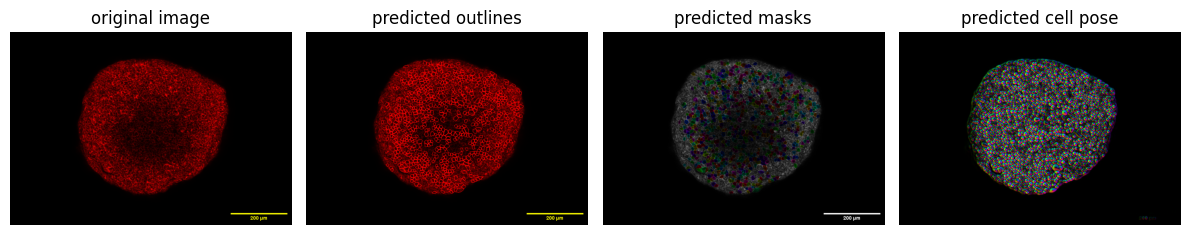

In [11]:
selected_channels = []
for i, c in enumerate([first_channel, second_channel, third_channel]):
  if c == 'None':
    continue
  if int(c) > img.shape[-1]:
    assert False, 'invalid channel index, must have index greater or equal to the number of channels'
  if c != 'None':
    selected_channels.append(int(c))



img_selected_channels = np.zeros_like(img)
img_selected_channels[:, :, :len(selected_channels)] = img[:, :, selected_channels]


flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

masks, flows, styles = model.eval(img_selected_channels, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

fig = plt.figure(figsize=(24,10))
plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
plt.tight_layout()
plt.show()


## Run Cellpose-SAM on folder of images

if you have many large images, you may want to run them as a loop over images



In [12]:
masks_ext = ".png" if image_ext == ".png" else ".tif"
for i in trange(len(files)):
    f = files[i]
    img = io.imread(f)
    masks, flows, styles = model.eval(img, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks)

 33%|███▎      | 3/9 [00:13<00:26,  4.41s/it]

2026-10-07 19:04:23,948 [dynamics INFO] No cell pixels found.


100%|██████████| 9/9 [01:03<00:00,  7.03s/it]


if you have small images, you may want to load all of them first and then run, so that they can be batched together on the GPU

In [ ]:
print("loading images")
imgs = [io.imread(files[i]) for i in trange(len(files))]

print("running cellpose-SAM")
masks, flows, styles = model.eval(imgs, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

print("saving masks")
for i in trange(len(files)):
    f = files[i]
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks[i])

to save your masks for ImageJ, run the following code:

In [ ]:
for i in trange(len(files)):
    f = files[i]
    io.imsave(dir / (f.name + "_masks" + masks_ext), masks[i])
    io.save_rois(masks[i], f)